### 3.4 – Advanced Analysis: Fraud Assessment Prediction

**Hypothesis:** Loan applications referred for fraud assessment (cases reaching `W_Assess potential fraud`) can be identified early from case-level and process-behaviour features, enabling proactive triage before costly manual review.

**Approach:** Three classifiers (Decision Tree, Naive Bayes, Random Forest) are compared in 5-fold stratified cross-validation on 10 features: 5 case-level attributes and 5 process-behaviour features.

In [2]:
import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import warnings, os
warnings.filterwarnings("ignore")

os.makedirs("../outputs", exist_ok=True)

df = pm4py.read_xes("../BPI.xes")
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True)

# Label: cases that ever reach W_Assess potential fraud
fraud_ids = set(df[df["concept:name"] == "W_Assess potential fraud"]["case:concept:name"])
df["is_fraud"] = df["case:concept:name"].isin(fraud_ids)

print(f"Total cases:  {df['case:concept:name'].nunique():,}")
print(f"Fraud cases:  {len(fraud_ids):,}  ({len(fraud_ids)/df['case:concept:name'].nunique()*100:.2f}%)")

Total cases:  31,509
Fraud cases:  303  (0.96%)


In [3]:
# ── Feature Engineering ──────────────────────────────────────────────────────
g  = df.sort_values("time:timestamp").groupby("case:concept:name")
le = LabelEncoder()

case_df = pd.DataFrame({
    "is_fraud":        g["is_fraud"].max().astype(int),
    # Case-level attributes
    "n_events":        g["concept:name"].count(),
    "n_unique_acts":   g["concept:name"].nunique(),
    "CreditScore":     g["CreditScore"].max(),
    "RequestedAmount": g["case:RequestedAmount"].first(),
    "LoanGoal":        g["case:LoanGoal"].first(),
    # Process-behaviour features
    "ApplicationType": g["case:ApplicationType"].first(),
    "case_duration":   (g["time:timestamp"].max() - g["time:timestamp"].min()).dt.total_seconds() / 86400,
    "n_offers":        g["concept:name"].apply(lambda x: x.str.startswith("O_").sum()),
    "n_work_items":    g["concept:name"].apply(lambda x: x.str.startswith("W_").sum()),
    "has_offer":       g["concept:name"].apply(lambda x: int(x.str.startswith("O_").any())),
})

case_df["LoanGoal"]        = le.fit_transform(case_df["LoanGoal"].fillna("Unknown"))
case_df["ApplicationType"] = le.fit_transform(case_df["ApplicationType"].fillna("Unknown"))
case_df = case_df.fillna(0)

FEATURES = ["n_events", "n_unique_acts", "CreditScore", "RequestedAmount", "LoanGoal",
            "ApplicationType", "case_duration", "n_offers", "n_work_items", "has_offer"]

X = case_df[FEATURES].values
y = case_df["is_fraud"].values

print(f"Cases: {len(case_df):,}  |  Fraud: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Cases: 31,509  |  Fraud: 303 (0.96%)
Features (10): ['n_events', 'n_unique_acts', 'CreditScore', 'RequestedAmount', 'LoanGoal', 'ApplicationType', 'case_duration', 'n_offers', 'n_work_items', 'has_offer']


In [4]:
# ── Significance Tests ────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu, chi2_contingency

ALPHA  = 0.05
fraud  = case_df[case_df["is_fraud"] == 1]
normal = case_df[case_df["is_fraud"] == 0]

rows = []
for feat in ["n_events", "n_unique_acts", "CreditScore", "RequestedAmount",
             "case_duration", "n_offers", "n_work_items", "has_offer"]:
    stat, p = mannwhitneyu(fraud[feat], normal[feat], alternative="two-sided")
    rows.append({"Feature": feat, "Test": "Mann-Whitney U", "p-value": p, "Significant": p < ALPHA})

for feat in ["LoanGoal", "ApplicationType"]:
    ct = pd.crosstab(case_df[feat], case_df["is_fraud"])
    chi2, p, _, _ = chi2_contingency(ct)
    rows.append({"Feature": feat, "Test": "Chi-squared", "p-value": p, "Significant": p < ALPHA})

sig_df = pd.DataFrame(rows).set_index("Feature")
print(f"α = {ALPHA}")
print(sig_df.to_string())

α = 0.05
                           Test       p-value  Significant
Feature                                                   
n_events         Mann-Whitney U  2.016981e-80         True
n_unique_acts    Mann-Whitney U  1.678655e-46         True
CreditScore      Mann-Whitney U  1.818502e-07         True
RequestedAmount  Mann-Whitney U  3.487004e-02         True
case_duration    Mann-Whitney U  2.597974e-03         True
n_offers         Mann-Whitney U  1.704612e-06         True
n_work_items     Mann-Whitney U  4.353975e-94         True
has_offer        Mann-Whitney U  1.000000e+00        False
LoanGoal            Chi-squared  6.532764e-03         True
ApplicationType     Chi-squared  1.167242e-06         True


In [5]:
# ── 3-Model Cross-Validation (10 features) ───────────────────────────────────
# class_weight='balanced' compensates for the 1:103 class imbalance (DT and RF).
# Naive Bayes has no class-weight support, included as a probabilistic baseline.
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Naive Bayes":   GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results   = {}
oof_probs = {}

for name, model in models.items():
    oof   = np.zeros(len(y))
    preds = np.zeros(len(y), dtype=int)
    for tr, va in skf.split(X, y):
        m = model.__class__(**model.get_params())
        m.fit(X[tr], y[tr])
        oof[va]   = m.predict_proba(X[va])[:, 1]
        preds[va] = m.predict(X[va])
    results[name] = dict(
        Accuracy  = accuracy_score(y, preds),
        Precision = precision_score(y, preds, zero_division=0),
        Recall    = recall_score(y, preds),
        F1        = f1_score(y, preds, zero_division=0),
    )
    oof_probs[name] = oof

print(pd.DataFrame(results).T.round(3).to_string())

               Accuracy  Precision  Recall     F1
Decision Tree     0.850      0.052   0.845  0.098
Naive Bayes       0.954      0.053   0.228  0.086
Random Forest     0.993      0.925   0.327  0.483


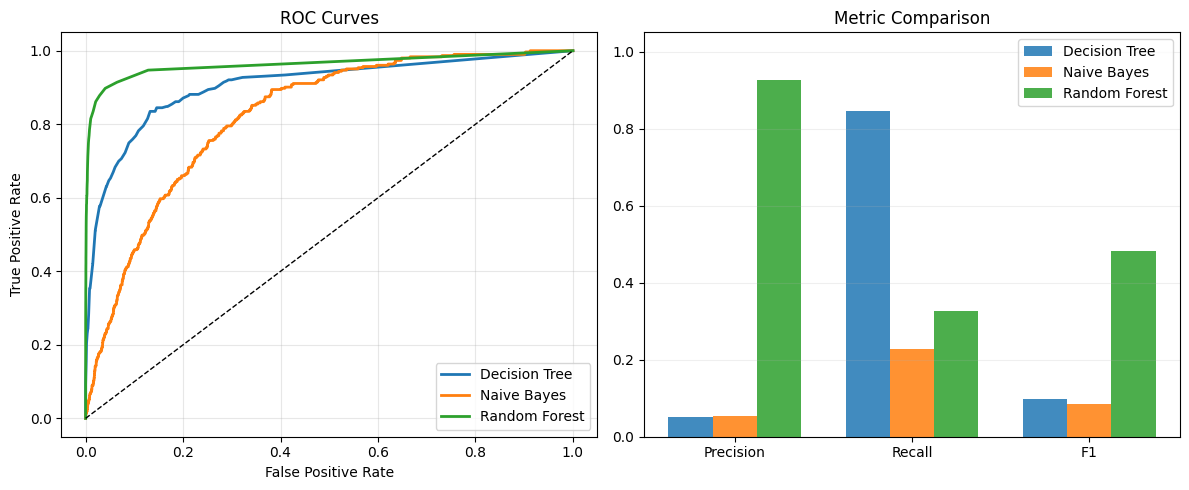

Saved: model_comparison.png


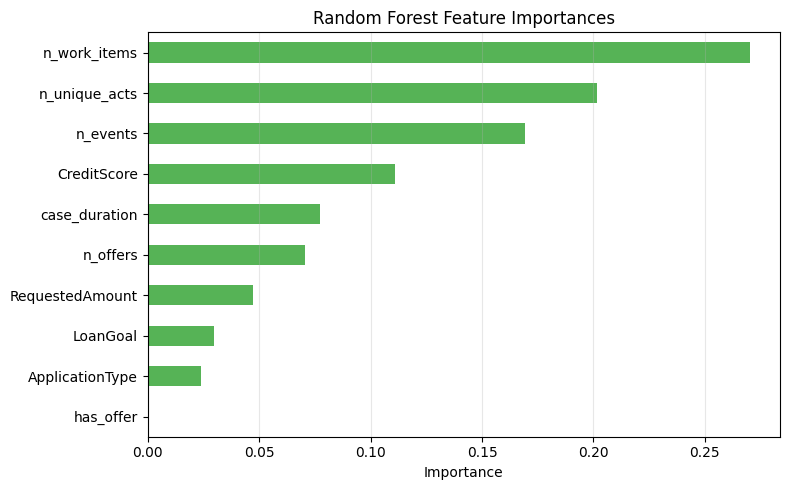

Saved: feature_importance.png


In [6]:
# ── ROC Curves + Metric Comparison ───────────────────────────────────────────
from sklearn.metrics import roc_curve
colors = {"Decision Tree": "#1f77b4", "Naive Bayes": "#ff7f0e", "Random Forest": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for name, oof in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, oof)
    ax.plot(fpr, tpr, color=colors[name], lw=2, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
metric_cols = ["Precision", "Recall", "F1"]
xi = np.arange(len(metric_cols)); w = 0.25
for i, (name, r) in enumerate(results.items()):
    ax.bar(xi + (i-1)*w, [r[m] for m in metric_cols], w,
           label=name, color=colors[name], alpha=0.85)
ax.set_xticks(xi); ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.05); ax.set_title("Metric Comparison")
ax.legend(); ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

# ── Random Forest Feature Importances ────────────────────────────────────────
rf_final = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
rf_final.fit(X, y)
importances = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="#2ca02c", alpha=0.8)
ax.set_title("Random Forest Feature Importances"); ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")